# Memory Encoding, Suppression, and Homeostatic Rescue
## Three-day protocol — four conditions

**All conditions share identical Day 1 (encoding). Conditions diverge only on Days 2–3:**

| Condition | Synaptic noise (dW) | Excitability OU (ε_i) |
|-----------|--------------------|-----------------------|
| Baseline  | no | no |
| A         | yes | no |
| B         | no | yes |
| C         | yes | yes |

**Day 2**: I = I_p < 0, homeostasis OFF  
**Day 3**: I = I_p stays, homeostasis ON — h(t) fights against suppression

In [1]:
import sys, os
from pathlib import Path
import numpy as np
import torch
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.notebook import tqdm

sys.path.insert(0, '../src')
from network import HebbianNetwork

DEVICE = 'cpu'
torch.manual_seed(42)
np.random.seed(42)

DATA_DIR = Path('../data')
FIG_DIR  = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

# --- Model parameters ---
N        = 10
dt       = 10.0    # ms
tau_r    = 10.0    # ms
tau_W    = 2000.0  # ms
tau_h    = 500.0   # ms
eta      = 0.005
lam      = 0.1
kappa_h  = 0.2     # increased to overcome I_p = -3
m_target = 0.5
W_scale  = 0.1

PARAMS = dict(N=N, dt=dt, tau_r=tau_r, tau_W=tau_W, tau_h=tau_h,
              eta=eta, lam=lam, kappa_h=kappa_h, m_target=m_target,
              W_scale=W_scale, seed=42, device=DEVICE)

# --- Simulation lengths ---
T_DAY1    = 2000   # 20 s
T_DAY2    = 2000   # 20 s
T_DAY3    = 2000   # 20 s
REC_EVERY = 10     # record every 100 ms

# --- Condition parameters ---
NOISE_STD = 0.01   # synaptic noise (conditions A, C)
TAU_EPS   = 1000.0 # ms  — slow OU timescale
SIGMA_EPS = 0.8    # OU amplitude (conditions B, C)

print('Parameters set. dt/tau_r =', dt/tau_r)

ModuleNotFoundError: No module named 'torch'

In [2]:
# Load or create I_base
try:
    I_base_np = np.load(DATA_DIR / 'I_base.npy')
    I_base = torch.tensor(I_base_np, dtype=torch.float32)
    print('Loaded I_base:', I_base_np)
except FileNotFoundError:
    indices_active = [0, 3, 4, 5, 7]
    amplitudes     = [1.2, 0.85, 1.48, 1.1, 0.95]
    I_base_np = np.zeros(N, dtype=np.float32)
    for i, amp in zip(indices_active, amplitudes):
        I_base_np[i] = amp
    I_base = torch.tensor(I_base_np, dtype=torch.float32)
    DATA_DIR.mkdir(exist_ok=True)
    np.save(DATA_DIR / 'I_base.npy', I_base_np)
    print('Created I_base:', I_base_np)

I_p = -3.0 * torch.ones(N, dtype=torch.float32)

Loaded I_base: [0.84608525 0.         0.         1.3208548  1.0877894  1.4817168
 0.         1.3395482  0.         0.        ]


In [3]:
# ============================================================
# DAY 1 — Memory Encoding  (shared across all conditions)
# ============================================================
net = HebbianNetwork(**PARAMS)
W_struct_np = net.W_struct.cpu().numpy().copy()

r_d1_hist  = []
W_d1_snaps = {}  # snapshots at 0s, ~7s, ~13s, 20s
snap_steps = {0: '0 s', T_DAY1//3: '7 s', 2*T_DAY1//3: '13 s', T_DAY1-1: '20 s'}

for t in tqdm(range(T_DAY1), desc='Day 1 encoding'):
    if t in snap_steps:
        W_d1_snaps[t] = net.W.cpu().numpy().copy()
    net.step(I_base, noise_std=0.0, homeostasis=False)
    if t % REC_EVERY == 0:
        r_d1_hist.append(net.r.cpu().numpy().copy())

r_d1_hist  = np.array(r_d1_hist)   # (150, 10)
r_m        = net.r.clone()          # memory reference pattern
W_d1       = net.W.clone()          # weights after encoding
r_d1_final = net.r.clone()
dW_d1_np   = W_d1.cpu().numpy() - W_struct_np

print(f'Day 1 done.')
print(f'  r_m mean = {r_m.mean():.3f},  max = {r_m.max():.3f}')
print(f'  ΔW max   = {dW_d1_np.max():.4f}')

Day 1 encoding:   0%|          | 0/2000 [00:00<?, ?it/s]

Day 1 done.
  r_m mean = 0.773,  max = 1.890
  ΔW max   = 0.0840


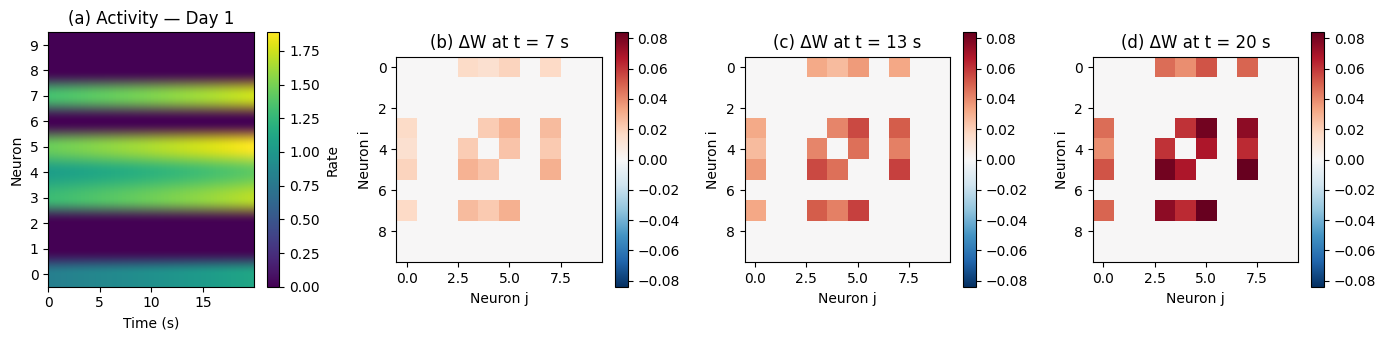

Saved fig_report1.png


In [4]:
# ============================================================
# fig_report1: Day 1 dynamics
# (a) neuron activity heatmap   (b-d) ΔW at t=5s, 10s, 15s
# ============================================================
%matplotlib inline
t_d1 = np.arange(len(r_d1_hist)) * REC_EVERY * dt / 1000.0

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

im0 = axes[0].imshow(r_d1_hist.T, aspect='auto', origin='lower',
                     extent=[0, t_d1[-1], -0.5, N-0.5],
                     cmap='viridis', vmin=0, vmax=r_d1_hist.max())
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Neuron')
axes[0].set_yticks(range(N))
axes[0].set_title('(a) Activity — Day 1')
plt.colorbar(im0, ax=axes[0], label='Rate')

snap_items = [(T_DAY1//3, '7 s'), (2*T_DAY1//3, '13 s'), (T_DAY1-1, '20 s')]
vmax_dW = max(abs(W_d1_snaps[T_DAY1-1] - W_struct_np).max(), 0.005)
for ax_idx, (snap_t, tlabel) in enumerate(snap_items, start=1):
    dW = W_d1_snaps[snap_t] - W_struct_np
    im = axes[ax_idx].imshow(dW, cmap='RdBu_r', vmin=-vmax_dW, vmax=vmax_dW, origin='upper')
    axes[ax_idx].set_title(f'({"bcd"[ax_idx-1]}) \u0394W at t = {tlabel}')
    axes[ax_idx].set_xlabel('Neuron j')
    axes[ax_idx].set_ylabel('Neuron i')
    plt.colorbar(im, ax=axes[ax_idx])

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_report1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_report1.png')

In [ ]:
# ============================================================
# RETRIEVAL TEST 1: Partial Cue (subset of original pattern)
# ============================================================
print('\n=== RETRIEVAL TEST: Partial Cue ===')
 
# Create partial cue: only neurons 0 and 3 get input (omit 4, 5, 7)
I_partial = torch.zeros(N, dtype=torch.float32)
I_partial[0] = I_base[0]  # 1.2
I_partial[3] = I_base[3]  # 0.85
 
# Reset rates but keep learned weights
net.r = torch.zeros(N, dtype=torch.float32, device=DEVICE)
 
r_retrieval_hist = []
 
for t in tqdm(range(T_RETRIEVAL), desc='Retrieval (partial cue)'):
    net.step(I_partial, noise_std=0.0, homeostasis=False)
    if t % REC_EVERY == 0:
        r_retrieval_hist.append(net.r.cpu().numpy().copy())
 
r_retrieval_hist = np.array(r_retrieval_hist)
r_retrieved = net.r.clone()
mfr_retrieval = r_retrieval_hist.mean(axis=1)
 
print(f'Retrieval done.')
print(f'  r_retrieved mean = {r_retrieved.mean():.3f},  max = {r_retrieved.max():.3f}')
 
# Compute pattern overlap with memory
overlap = torch.dot(r_retrieved, r_m) / (torch.norm(r_retrieved) * torch.norm(r_m))
print(f'  Pattern overlap with r_m: {overlap:.3f}')
 
# Check which neurons were recruited
recruited = (r_retrieved > 0.1).cpu().numpy()  # threshold at 0.1
print(f'  Neurons recruited: {np.where(recruited)[0]}')
print(f'  Original active: [0, 3, 4, 5, 7]')
 
# ============================================================
# VISUALIZATION 1: Mean Firing Rate Dynamics
# ============================================================
print('\n=== Creating MFR visualization ===')
 
t_baseline = np.arange(len(r_baseline_hist)) * REC_EVERY * dt / 1000.0
t_encoding = np.arange(len(r_d1_hist)) * REC_EVERY * dt / 1000.0
t_retrieval = np.arange(len(r_retrieval_hist)) * REC_EVERY * dt / 1000.0
 
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
 
# Panel A: MFR across all three epochs
ax = axes[0]
ax.axvspan(0, t_baseline[-1], alpha=0.2, color='gray', label='Baseline')
ax.axvspan(t_baseline[-1], t_baseline[-1] + t_encoding[-1], alpha=0.2, color='orange', label='Encoding')
ax.axvspan(t_baseline[-1] + t_encoding[-1], 
           t_baseline[-1] + t_encoding[-1] + t_retrieval[-1], 
           alpha=0.2, color='green', label='Retrieval')
 
# Plot MFR
t_baseline_shifted = t_baseline
t_encoding_shifted = t_encoding + t_baseline[-1]
t_retrieval_shifted = t_retrieval + t_baseline[-1] + t_encoding[-1]
 
ax.plot(t_baseline_shifted, mfr_baseline, 'k-', linewidth=2, label='MFR')
ax.plot(t_encoding_shifted, mfr_encoding, 'k-', linewidth=2)
ax.plot(t_retrieval_shifted, mfr_retrieval, 'k-', linewidth=2)
 
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Mean Firing Rate (Hz)', fontsize=12)
ax.set_title('(A) Population Mean Firing Rate Across Epochs', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
 
# Panel B: Individual neuron traces during encoding and retrieval
ax = axes[1]
 
# Show encoding (left half) and retrieval (right half) side by side
active_neurons = [0, 3, 4, 5, 7]
colors = plt.cm.tab10(np.linspace(0, 1, 10))
 
# Encoding traces
for neuron_idx in range(N):
    if neuron_idx in active_neurons:
        ax.plot(t_encoding, r_d1_hist[:, neuron_idx], 
                color=colors[neuron_idx], linewidth=2, 
                label=f'N{neuron_idx} (active)')
    else:
        ax.plot(t_encoding, r_d1_hist[:, neuron_idx], 
                color=colors[neuron_idx], linewidth=1, alpha=0.4,
                linestyle='--', label=f'N{neuron_idx} (silent)')
 
# Add vertical separator
ax.axvline(t_encoding[-1], color='red', linestyle='--', linewidth=2, label='Switch to retrieval')
 
# Retrieval traces (shifted to continue timeline)
for neuron_idx in range(N):
    if neuron_idx in active_neurons:
        ax.plot(t_retrieval + t_encoding[-1], r_retrieval_hist[:, neuron_idx], 
                color=colors[neuron_idx], linewidth=2)
    else:
        ax.plot(t_retrieval + t_encoding[-1], r_retrieval_hist[:, neuron_idx], 
                color=colors[neuron_idx], linewidth=1, alpha=0.4, linestyle='--')
 
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Firing Rate (Hz)', fontsize=12)
ax.set_title('(B) Individual Neuron Activity: Encoding → Retrieval (Partial Cue)', 
             fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_mfr_dynamics.png', dpi=150, bbox_inches='tight')
plt.close()
print('Saved fig_mfr_dynamics.png')
 
# ============================================================
# VISUALIZATION 2: Retrieval Performance
# ============================================================
print('=== Creating retrieval comparison ===')
 
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
 
# Panel A: Input patterns
ax = axes[0]
patterns = np.vstack([I_base.cpu().numpy(), I_partial.cpu().numpy()])
im = ax.imshow(patterns, aspect='auto', cmap='viridis', vmin=0, vmax=patterns.max())
ax.set_yticks([0, 1])
ax.set_yticklabels(['Full', 'Partial'])
ax.set_xlabel('Neuron')
ax.set_title('(A) Input Patterns')
plt.colorbar(im, ax=ax, label='Input Current')
 
# Panel B: Encoded memory pattern
ax = axes[1]
im = ax.bar(range(N), r_m.cpu().numpy(), color='orange', alpha=0.7)
ax.set_xlabel('Neuron')
ax.set_ylabel('Firing Rate')
ax.set_title(f'(B) Encoded Memory\n(MFR={r_m.mean():.3f})')
ax.set_ylim([0, max(r_m.max().item(), r_retrieved.max().item()) * 1.1])
 
# Panel C: Retrieved pattern
ax = axes[2]
im = ax.bar(range(N), r_retrieved.cpu().numpy(), color='green', alpha=0.7)
ax.set_xlabel('Neuron')
ax.set_ylabel('Firing Rate')
ax.set_title(f'(C) Retrieved Pattern\n(Overlap={overlap:.3f})')
ax.set_ylim([0, max(r_m.max().item(), r_retrieved.max().item()) * 1.1])
 
# Panel D: Overlay comparison
ax = axes[3]
x = np.arange(N)
width = 0.35
ax.bar(x - width/2, r_m.cpu().numpy(), width, label='Encoded', alpha=0.7, color='orange')
ax.bar(x + width/2, r_retrieved.cpu().numpy(), width, label='Retrieved', alpha=0.7, color='green')
ax.set_xlabel('Neuron')
ax.set_ylabel('Firing Rate')
ax.set_title('(D) Encoded vs Retrieved')
ax.legend()
 
# Highlight which neurons were cued
for idx in [0, 3]:
    ax.axvspan(idx - 0.5, idx + 0.5, alpha=0.2, color='blue')
ax.text(0.5, ax.get_ylim()[1] * 0.95, 'Cued', fontsize=9, ha='center')
 
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_retrieval_test.png', dpi=150, bbox_inches='tight')
plt.close()
print('Saved fig_retrieval_test.png')
 
# ============================================================
# VISUALIZATION 3: Original Day 1 dynamics figure
# ============================================================
print('=== Creating Day 1 weight dynamics ===')
 
t_d1 = np.arange(len(r_d1_hist)) * REC_EVERY * dt / 1000.0
 
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
 
im0 = axes[0].imshow(r_d1_hist.T, aspect='auto', origin='lower',
                     extent=[0, t_d1[-1], -0.5, N-0.5],
                     cmap='viridis', vmin=0, vmax=r_d1_hist.max())
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Neuron')
axes[0].set_yticks(range(N))
axes[0].set_title('(a) Activity — Day 1')
plt.colorbar(im0, ax=axes[0], label='Rate')
 
snap_items = [(T_DAY1//3, '7 s'), (2*T_DAY1//3, '13 s'), (T_DAY1-1, '20 s')]
vmax_dW = max(abs(W_d1_snaps[T_DAY1-1] - W_struct_np).max(), 0.005)
for ax_idx, (snap_t, tlabel) in enumerate(snap_items, start=1):
    dW = W_d1_snaps[snap_t] - W_struct_np
    im = axes[ax_idx].imshow(dW, cmap='RdBu_r', vmin=-vmax_dW, vmax=vmax_dW, origin='upper')
    axes[ax_idx].set_title(f'({"bcd"[ax_idx-1]}) ΔW at t = {tlabel}')
    axes[ax_idx].set_xlabel('Neuron j')
    axes[ax_idx].set_ylabel('Neuron i')
    plt.colorbar(im, ax=axes[ax_idx])
 
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_report1.png', dpi=150, bbox_inches='tight')
plt.close()
print('Saved fig_report1.png')
 
# ============================================================
# Summary Statistics
# ============================================================
print('\n' + '='*60)
print('SUMMARY STATISTICS')
print('='*60)
print(f'\nBASELINE (no input):')
print(f'  MFR = {mfr_baseline.mean():.4f} ± {mfr_baseline.std():.4f}')
 
print(f'\nENCODING (full pattern):')
print(f'  MFR = {mfr_encoding.mean():.4f} ± {mfr_encoding.std():.4f}')
print(f'  Active neurons: {np.sum(r_m.cpu().numpy() > 0.1)}/{N}')
print(f'  Max ΔW: {dW_d1_np.max():.4f}')
 
print(f'\nRETRIEVAL (partial cue - neurons 0, 3 only):')
print(f'  MFR = {mfr_retrieval.mean():.4f} ± {mfr_retrieval.std():.4f}')
print(f'  Neurons recruited: {np.where(recruited)[0]}')
print(f'  Pattern overlap: {overlap:.3f}')
print(f'  Expected recruitment: [0, 3, 4, 5, 7]')
 
# Pattern completion success
expected_recruitment = np.array([0, 3, 4, 5, 7])
actual_recruitment = np.where(recruited)[0]
recall_success = len(np.intersect1d(expected_recruitment, actual_recruitment)) / len(expected_recruitment)
print(f'  Recall success rate: {recall_success:.1%}')
 
print('\n' + '='*60)
print('All figures saved to:', FIG_DIR)
print('='*60)

In [5]:
# ============================================================
# Run all four conditions: Days 2 and 3
# All start from the same W_d1, r_d1_final
# ============================================================
CONDITIONS = {
    'Baseline':  {'noise_std': 0.0,       'use_eps': False, 'color': 'black',      'ls': '-'},
    'A: noise':  {'noise_std': NOISE_STD,  'use_eps': False, 'color': 'tab:blue',   'ls': '--'},
    'B: excit.': {'noise_std': 0.0,        'use_eps': True,  'color': 'tab:orange', 'ls': '-.'},
    'C: both':   {'noise_std': NOISE_STD,  'use_eps': True,  'color': 'tab:red',    'ls': ':'},
}

r_m_np   = r_m.cpu().numpy()
r_m_norm = np.linalg.norm(r_m_np)

results = {}
for cond_idx, (cond_name, params) in enumerate(CONDITIONS.items()):
    torch.manual_seed(cond_idx + 10)
    np.random.seed(cond_idx + 10)

    net.W       = W_d1.clone()
    net.r       = r_d1_final.clone()
    net.h       = torch.tensor(0.0)
    net.epsilon = torch.zeros(N)

    r_d2_hist, r_d3_hist, h_d3_hist = [], [], []

    # Day 2: I_p, homeostasis OFF
    trace_d2_hist = []
    for t in tqdm(range(T_DAY2), desc=f'Day 2 [{cond_name}]', leave=False):
        if params['use_eps']:
            drift = -net.epsilon / TAU_EPS
            diff  = SIGMA_EPS * (2.0 * dt / TAU_EPS) ** 0.5
            net.epsilon = net.epsilon + dt * drift + diff * torch.randn(N)
        net.step(I_p, noise_std=params['noise_std'], homeostasis=False)
        if t % REC_EVERY == 0:
            r_d2_hist.append(net.r.cpu().numpy().copy())
            trace_d2_hist.append(np.abs(net.W.cpu().numpy() - W_struct_np).mean())

    W_end_d2 = net.W.cpu().numpy().copy()

    # Day 3: I_p stays, homeostasis ON
    trace_d3_hist = []
    for t in tqdm(range(T_DAY3), desc=f'Day 3 [{cond_name}]', leave=False):
        if params['use_eps']:
            drift = -net.epsilon / TAU_EPS
            diff  = SIGMA_EPS * (2.0 * dt / TAU_EPS) ** 0.5
            net.epsilon = net.epsilon + dt * drift + diff * torch.randn(N)
        net.step(I_p, noise_std=params['noise_std'], homeostasis=True)
        if t % REC_EVERY == 0:
            r_d3_hist.append(net.r.cpu().numpy().copy())
            h_d3_hist.append(net.h.item())
            trace_d3_hist.append(np.abs(net.W.cpu().numpy() - W_struct_np).mean())

    W_end_d3 = net.W.cpu().numpy().copy()

    r_d2_arr = np.array(r_d2_hist)
    r_d3_arr = np.array(r_d3_hist)
    h_d3_arr = np.array(h_d3_hist)

    results[cond_name] = dict(
        r_d2=r_d2_arr, r_d3=r_d3_arr,
        m_mem_d1=r_d1_hist @ r_m_np / r_m_norm,
        m_mem_d2=r_d2_arr  @ r_m_np / r_m_norm,
        m_mem_d3=r_d3_arr  @ r_m_np / r_m_norm,
        m_mean_d2=r_d2_arr.mean(axis=1), m_mean_d3=r_d3_arr.mean(axis=1),
        h_d3=h_d3_arr, W_end_d2=W_end_d2, W_end_d3=W_end_d3,
        trace_d2=np.array(trace_d2_hist), trace_d3=np.array(trace_d3_hist),
        **{k: v for k, v in params.items()}
    )
    print(f'{cond_name:12s}  m_mem D3={results[cond_name]["m_mem_d3"][-1]:.3f}'
          f'  h={h_d3_arr[-1]:.3f}  m_mean D3={r_d3_arr[-1].mean():.3f}')
print('All conditions done.')

Day 2 [Baseline]:   0%|          | 0/2000 [00:00<?, ?it/s]

Day 3 [Baseline]:   0%|          | 0/2000 [00:00<?, ?it/s]

Baseline      m_mem D3=1.100  h=3.492  m_mean D3=0.502


Day 2 [A: noise]:   0%|          | 0/2000 [00:00<?, ?it/s]

Day 3 [A: noise]:   0%|          | 0/2000 [00:00<?, ?it/s]

...

Day 3 [B: excit.]:   0%|          | 0/2000 [00:00<?, ?it/s]

B: excit.     m_mem D3=2.885  h=3.249  m_mean D3=0.844


Day 2 [C: both]:   0%|          | 0/2000 [00:00<?, ?it/s]

Day 3 [C: both]:   0%|          | 0/2000 [00:00<?, ?it/s]

C: both       m_mem D3=1.236  h=3.633  m_mean D3=0.548
All conditions done.


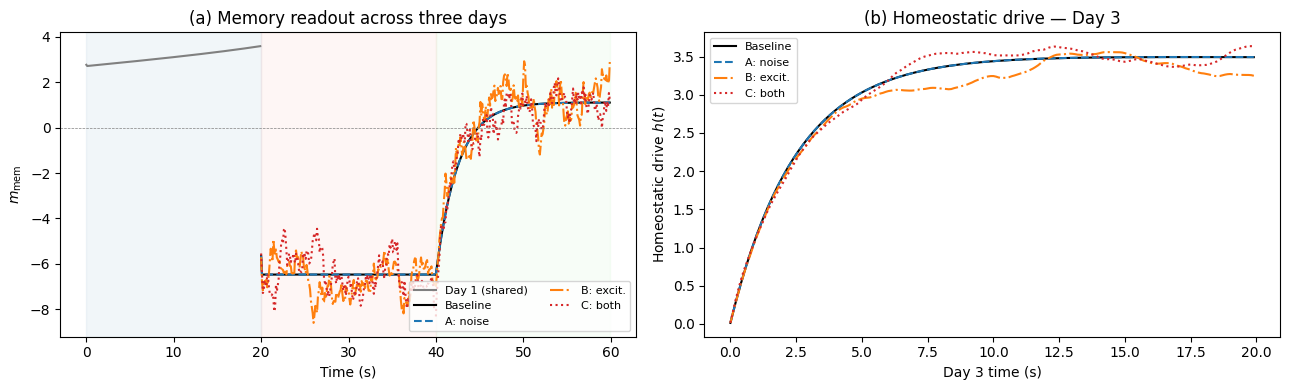

Saved fig_report2.png


In [6]:
# ============================================================
# fig_report2: m_mem across all 3 days + h(t) on Day 3
# ============================================================
base  = list(results.values())[0]
t_d2  = np.arange(len(base['r_d2'])) * REC_EVERY * dt / 1000.0
t_d3  = np.arange(len(base['r_d3'])) * REC_EVERY * dt / 1000.0
gap   = REC_EVERY * dt / 1000.0
off2  = t_d1[-1] + gap
off3  = off2 + t_d2[-1] + gap

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for cond_name, res in results.items():
    c, ls = res['color'], res['ls']
    if cond_name == 'Baseline':
        ax.plot(t_d1, res['m_mem_d1'], color='gray', lw=1.5, label='Day 1 (shared)')
    ax.plot(off2 + t_d2, res['m_mem_d2'], color=c, ls=ls, lw=1.5)
    ax.plot(off3 + t_d3, res['m_mem_d3'], color=c, ls=ls, lw=1.5, label=cond_name)

for x0, x1, col in [(0, off2, 'steelblue'), (off2, off3, 'salmon'), (off3, off3+t_d3[-1], 'lightgreen')]:
    ax.axvspan(x0, x1, alpha=0.07, color=col)

ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$m_{\mathrm{mem}}$')
ax.set_title('(a) Memory readout across three days')
ax.legend(fontsize=8, loc='lower right', ncol=2)

ax2 = axes[1]
for cond_name, res in results.items():
    ax2.plot(t_d3, res['h_d3'], color=res['color'], ls=res['ls'], lw=1.5, label=cond_name)
ax2.set_xlabel('Day 3 time (s)')
ax2.set_ylabel('Homeostatic drive $h(t)$')
ax2.set_title('(b) Homeostatic drive — Day 3')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_report2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_report2.png')

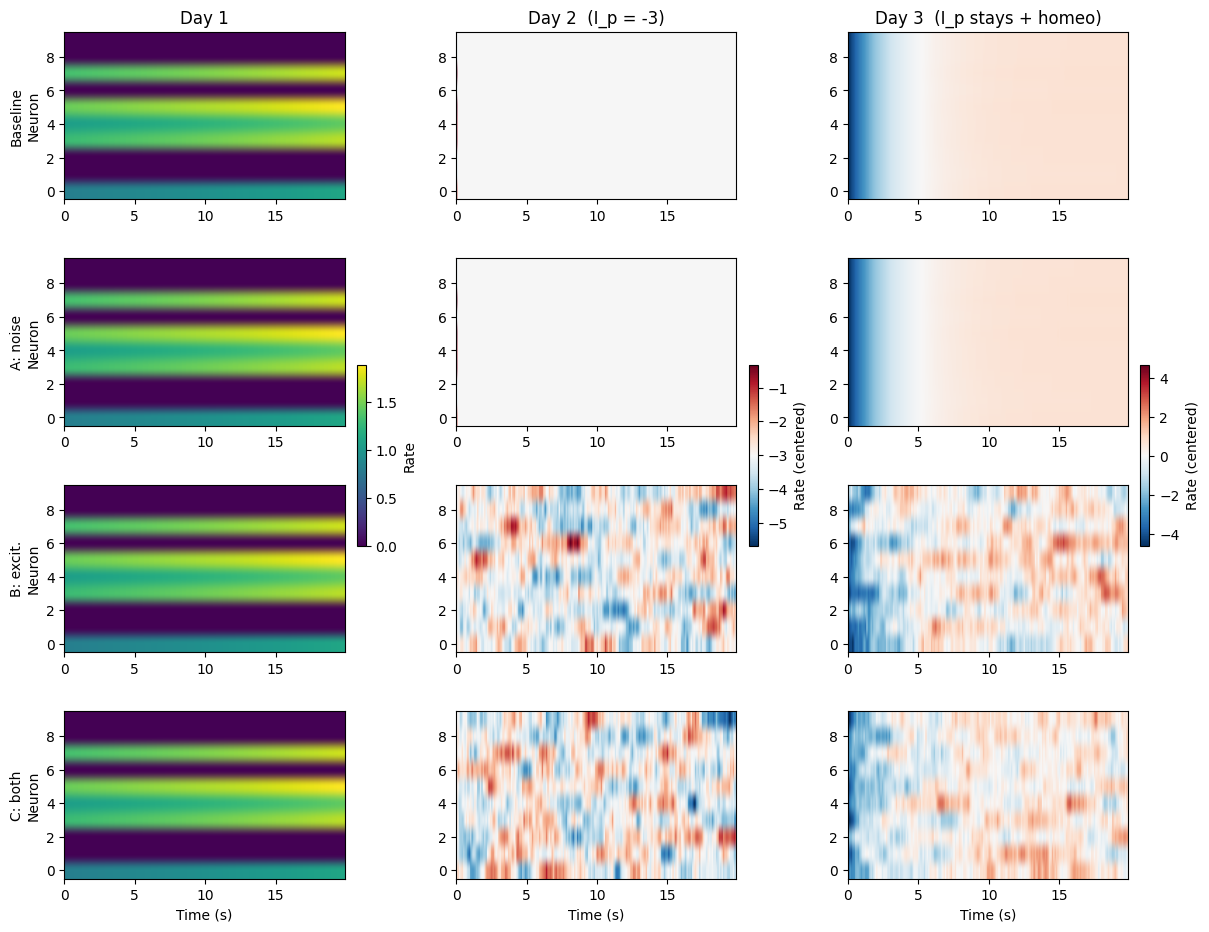

Saved fig_activity_heatmaps.png


In [7]:
# ============================================================
# Figure: Activity heatmaps — 4 conditions × 3 days
# ============================================================
cond_names = list(results.keys())
fig, axes = plt.subplots(4, 3, figsize=(14, 11))
plt.subplots_adjust(hspace=0.35, wspace=0.3)

for row, cond_name in enumerate(cond_names):
    res = results[cond_name]

    im0 = axes[row, 0].imshow(r_d1_hist.T, aspect='auto', origin='lower',
                               extent=[0, t_d1[-1], -0.5, N-0.5],
                               cmap='viridis', vmin=0, vmax=r_d1_hist.max())
    axes[row, 0].set_ylabel(f'{cond_name}\nNeuron')
    if row == 0: axes[row, 0].set_title('Day 1')

    r_d2_data = res['r_d2']
    d2_mean = r_d2_data.mean()
    d2_dev  = np.abs(r_d2_data - d2_mean).max()
    d2_dev  = max(d2_dev, 0.05)
    im1 = axes[row, 1].imshow(r_d2_data.T, aspect='auto', origin='lower',
                               extent=[0, t_d2[-1], -0.5, N-0.5],
                               cmap='RdBu_r', vmin=d2_mean - d2_dev, vmax=d2_mean + d2_dev)
    if row == 0: axes[row, 1].set_title('Day 2  (I_p = -3)')

    r_d3_end = res['r_d3']  # shape (T, N)
    d3_mean = r_d3_end.mean()
    d3_dev  = np.abs(r_d3_end - d3_mean).max()
    d3_dev  = max(d3_dev, 0.05)
    im2 = axes[row, 2].imshow(r_d3_end.T, aspect='auto', origin='lower',
                               extent=[0, t_d3[-1], -0.5, N-0.5],
                               cmap='RdBu_r', vmin=d3_mean - d3_dev, vmax=d3_mean + d3_dev)
    if row == 0: axes[row, 2].set_title('Day 3  (I_p stays + homeo)')

for ax in axes[-1]: ax.set_xlabel('Time (s)')
fig.colorbar(im0, ax=axes[:, 0], label='Rate', fraction=0.03, pad=0.04)
fig.colorbar(im1, ax=axes[:, 1], label='Rate (centered)', fraction=0.03, pad=0.04)
fig.colorbar(im2, ax=axes[:, 2], label='Rate (centered)', fraction=0.03, pad=0.04)

plt.savefig(FIG_DIR / 'fig_activity_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_activity_heatmaps.png')

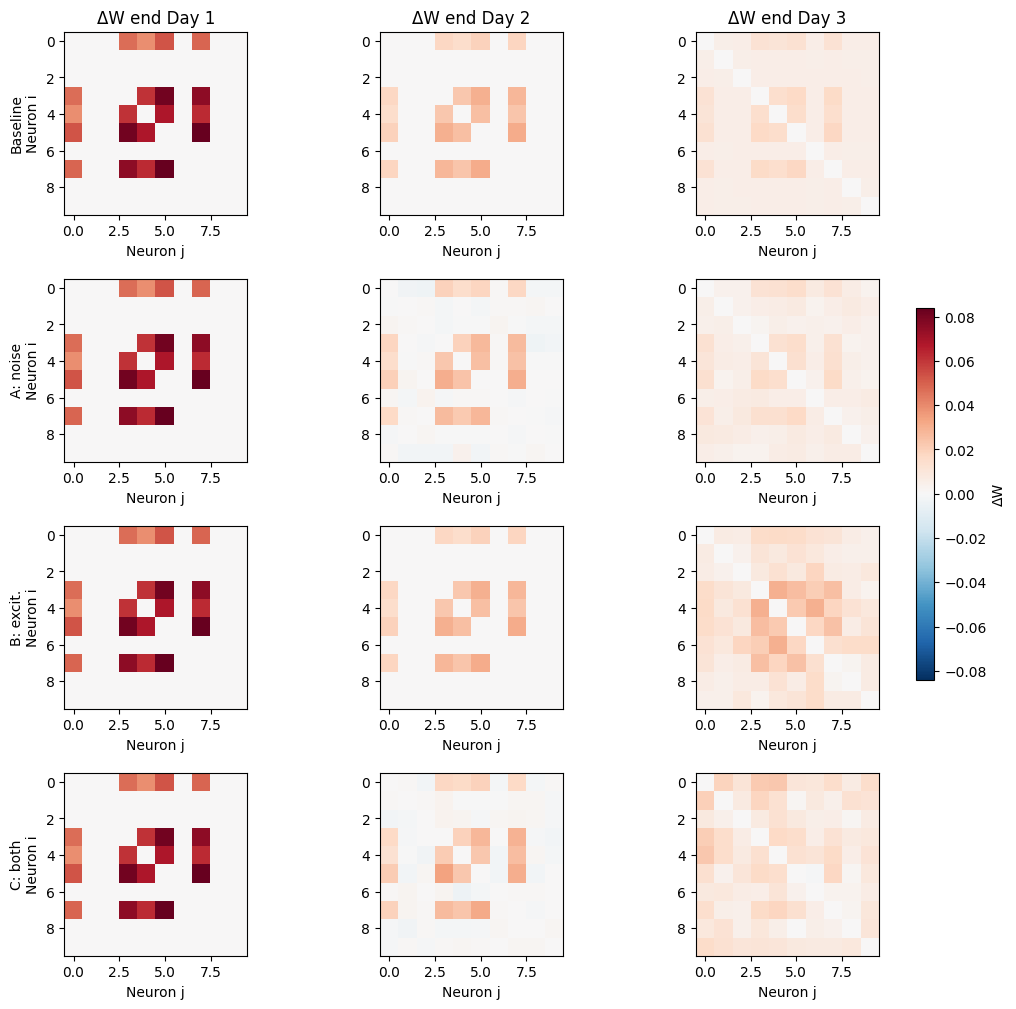

Saved fig_W_grid.png


In [8]:
# ============================================================
# Figure: Delta-W colormaps — 4 conditions × 3 days
# ============================================================
fig, axes = plt.subplots(4, 3, figsize=(12, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.3)

all_dW_vals = [dW_d1_np]
for res in results.values():
    all_dW_vals += [res['W_end_d2'] - W_struct_np, res['W_end_d3'] - W_struct_np]
vmax_dW = max(abs(m).max() for m in all_dW_vals)
vmax_dW = max(vmax_dW, 1e-6)

for row, cond_name in enumerate(cond_names):
    res = results[cond_name]

    im0 = axes[row, 0].imshow(dW_d1_np, cmap='RdBu_r', vmin=-vmax_dW, vmax=vmax_dW, origin='upper')
    axes[row, 0].set_ylabel(f'{cond_name}\nNeuron i')
    if row == 0: axes[row, 0].set_title('\u0394W end Day 1')

    im1 = axes[row, 1].imshow(res['W_end_d2'] - W_struct_np,
                               cmap='RdBu_r', vmin=-vmax_dW, vmax=vmax_dW, origin='upper')
    if row == 0: axes[row, 1].set_title('\u0394W end Day 2')

    im2 = axes[row, 2].imshow(res['W_end_d3'] - W_struct_np,
                               cmap='RdBu_r', vmin=-vmax_dW, vmax=vmax_dW, origin='upper')
    if row == 0: axes[row, 2].set_title('\u0394W end Day 3')

for ax_row in axes:
    for ax in ax_row: ax.set_xlabel('Neuron j')
fig.colorbar(im2, ax=axes.ravel().tolist(), label='\u0394W', fraction=0.02, pad=0.04)
plt.savefig(FIG_DIR / 'fig_W_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_W_grid.png')

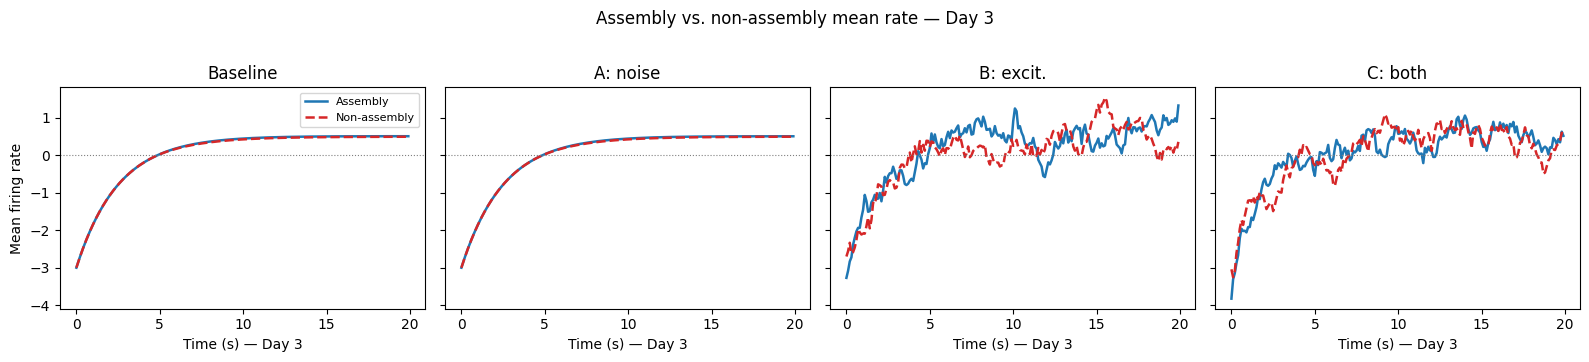

Saved fig_assembly_rates.png


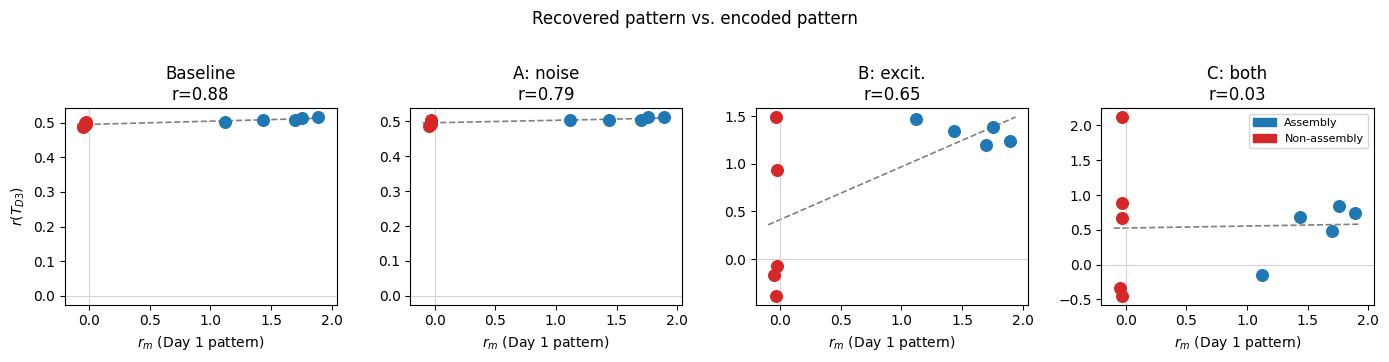

Saved fig_pattern_scatter.png


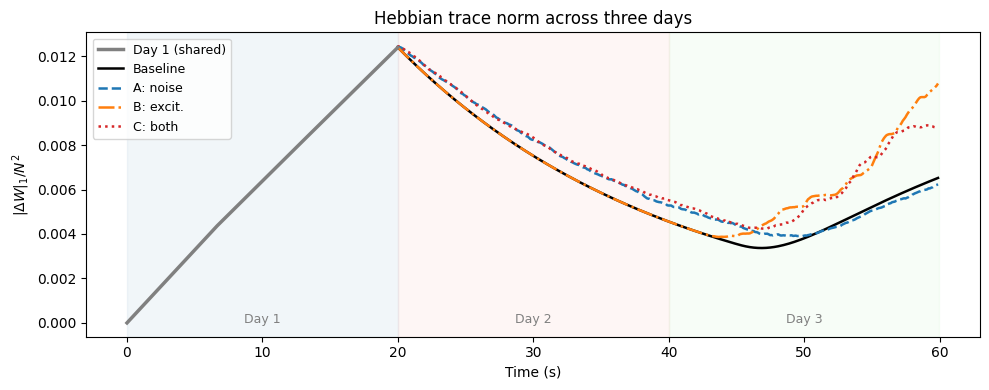

Saved fig_trace_norm.png


In [9]:
# ============================================================
# Figure 1: Assembly vs. non-assembly mean rate on Day 3
# ============================================================
assembly_idx     = [0, 3, 4, 5, 7]
non_assembly_idx = [1, 2, 6, 8, 9]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)
for ax, (cond_name, res) in zip(axes, results.items()):
    r_d3  = res['r_d3']
    t_ax  = np.arange(len(r_d3)) * REC_EVERY * dt / 1000.0

    mean_asm  = r_d3[:, assembly_idx].mean(axis=1)
    mean_non  = r_d3[:, non_assembly_idx].mean(axis=1)

    ax.plot(t_ax, mean_asm,  color='tab:blue', lw=1.8, label='Assembly')
    ax.plot(t_ax, mean_non,  color='tab:red',  lw=1.8, ls='--', label='Non-assembly')
    ax.axhline(0, color='gray', lw=0.8, ls=':')
    ax.set_title(cond_name)
    ax.set_xlabel('Time (s) — Day 3')
axes[0].set_ylabel('Mean firing rate')
axes[0].legend(fontsize=8)
plt.suptitle('Assembly vs. non-assembly mean rate — Day 3', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_assembly_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_assembly_rates.png')

# ============================================================
# Figure 2: Final pattern scatter r(T) vs r_m
# ============================================================
r_m_np = r_m.cpu().numpy()
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

for ax, (cond_name, res) in zip(axes, results.items()):
    r_final = res['r_d3'][-1]
    corr    = np.corrcoef(r_m_np, r_final)[0, 1]
    colors_pt = ['tab:blue' if i in assembly_idx else 'tab:red' for i in range(N)]
    for i in range(N):
        ax.scatter(r_m_np[i], r_final[i], color=colors_pt[i], s=70, zorder=3)
    m_coef, b_coef = np.polyfit(r_m_np, r_final, 1)
    xmin, xmax = r_m_np.min() - 0.05, r_m_np.max() + 0.05
    ax.plot([xmin, xmax], [m_coef*xmin+b_coef, m_coef*xmax+b_coef],
            color='gray', lw=1.2, ls='--')
    ax.axhline(0, color='lightgray', lw=0.8)
    ax.axvline(0, color='lightgray', lw=0.8)
    ax.set_title(f'{cond_name}\nr={corr:.2f}')
    ax.set_xlabel(r'$r_m$ (Day 1 pattern)')

axes[0].set_ylabel(r'$r(T_{D3})$')
from matplotlib.patches import Patch
leg = [Patch(color='tab:blue', label='Assembly'), Patch(color='tab:red', label='Non-assembly')]
axes[-1].legend(handles=leg, fontsize=8)
plt.suptitle('Recovered pattern vs. encoded pattern', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_pattern_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_pattern_scatter.png')

# ============================================================
# Figure 3: Hebbian trace norm |ΔW|_1/N^2 over all 3 days
# ============================================================
dW_d1_np = W_d1.cpu().numpy() - W_struct_np
snap_times_s = sorted(W_d1_snaps.keys())
trace_d1_arr  = np.array([np.abs(W_d1_snaps[t] - W_struct_np).mean() for t in snap_times_s])
t_d1_snaps    = np.array([t * dt / 1000.0 for t in snap_times_s])

t_d2_arr = np.arange(len(list(results.values())[0]['trace_d2'])) * REC_EVERY * dt / 1000.0
t_d3_arr = np.arange(len(list(results.values())[0]['trace_d3'])) * REC_EVERY * dt / 1000.0
off2 = t_d1_snaps[-1]
off3 = off2 + T_DAY2 * dt / 1000.0

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_d1_snaps, trace_d1_arr, color='gray', lw=2.5, label='Day 1 (shared)', zorder=5)

for cond_name, res in results.items():
    col = res['color']
    ls  = res['ls']
    # stitch Day1 end → Day2 → Day3
    t_full   = np.concatenate([[off2],       off2 + t_d2_arr,         off3 + t_d3_arr])
    tr_full  = np.concatenate([[trace_d1_arr[-1]], res['trace_d2'],   res['trace_d3']])
    ax.plot(t_full, tr_full, color=col, ls=ls, lw=1.8, label=cond_name)

ax.axvspan(0,    off2, alpha=0.07, color='steelblue')
ax.axvspan(off2, off3, alpha=0.07, color='salmon')
ax.axvspan(off3, off3 + T_DAY3 * dt / 1000.0, alpha=0.07, color='lightgreen')
for xv, lbl in [(off2/2, 'Day 1'), (off2 + (off3-off2)/2, 'Day 2'), (off3 + T_DAY3*dt/2000.0, 'Day 3')]:
    ax.text(xv, ax.get_ylim()[0] if False else 0, lbl, ha='center', fontsize=9, color='gray')
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$|\Delta W|_1 / N^2$')
ax.set_title('Hebbian trace norm across three days')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_trace_norm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_trace_norm.png')


Seeds:   0%|          | 0/20 [00:00<?, ?it/s]


=== Robustness (n=20 seeds, 20-20-20 protocol) ===
  Baseline      mean=1.100  std=0.000  min=1.100  max=1.100
  A: noise      mean=1.100  std=0.002  min=1.097  max=1.105
  B: excit.     mean=0.962  std=0.744  min=-0.398  max=2.461
  C: both       mean=0.956  std=0.743  min=-0.825  max=2.346


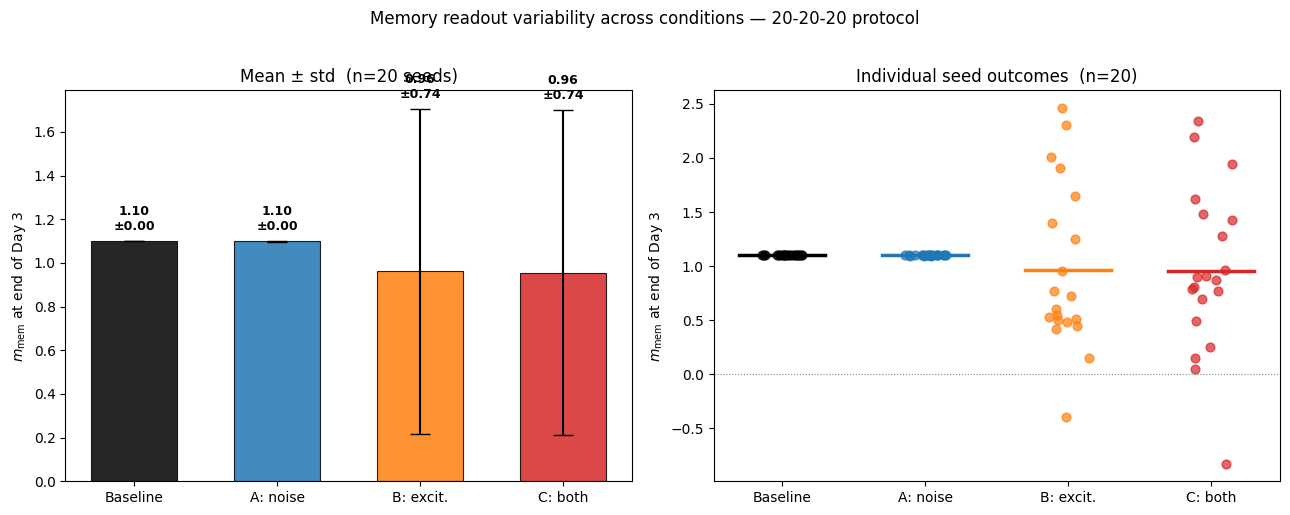

Saved fig_robustness.png


In [10]:
# ============================================================
# Robustness: m_mem over 20 random seeds (main result figure)
# Shows that Baseline and A are deterministic; B and C are stochastic
# ============================================================
N_SEEDS = 20

from collections import defaultdict
seed_results = defaultdict(list)

for s_idx in tqdm(range(N_SEEDS), desc='Seeds'):
    _net = HebbianNetwork(**PARAMS)
    # Day 1 (always seed=42 for encoding, only Days 2-3 vary)
    for t in range(T_DAY1):
        _net.step(I_base, noise_std=0.0, homeostasis=False)
    _W_d1 = _net.W.clone(); _r_d1 = _net.r.clone()
    _r_m_np = _r_d1.cpu().numpy(); _r_m_norm = np.linalg.norm(_r_m_np)

    for ci, (cond_name, params) in enumerate(CONDITIONS.items()):
        torch.manual_seed(s_idx * 100 + ci)
        np.random.seed(s_idx * 100 + ci)
        _net.W = _W_d1.clone(); _net.r = _r_d1.clone()
        _net.h = torch.tensor(0.0); _net.epsilon = torch.zeros(N)

        for t in range(T_DAY2):
            if params['use_eps']:
                drift = -_net.epsilon / TAU_EPS
                diff  = SIGMA_EPS * (2.0 * dt / TAU_EPS) ** 0.5
                _net.epsilon = _net.epsilon + dt * drift + diff * torch.randn(N)
            _net.step(I_p, noise_std=params['noise_std'], homeostasis=False)

        for t in range(T_DAY3):
            if params['use_eps']:
                drift = -_net.epsilon / TAU_EPS
                diff  = SIGMA_EPS * (2.0 * dt / TAU_EPS) ** 0.5
                _net.epsilon = _net.epsilon + dt * drift + diff * torch.randn(N)
            _net.step(I_p, noise_std=params['noise_std'], homeostasis=True)

        seed_results[cond_name].append(_net.r.cpu().numpy() @ _r_m_np / _r_m_norm)

# Print stats
print("\n=== Robustness (n=20 seeds, 20-20-20 protocol) ===")
for cname in CONDITIONS:
    vals = np.array(seed_results[cname])
    print(f"  {cname:12s}  mean={vals.mean():.3f}  std={vals.std():.3f}  min={vals.min():.3f}  max={vals.max():.3f}")

# Figure: bar + individual seed scatter
cond_names = list(CONDITIONS.keys())
colors = [CONDITIONS[c]['color'] for c in cond_names]
x = np.arange(len(cond_names))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: bar + error
ax = axes[0]
means = [np.mean(seed_results[c]) for c in cond_names]
stds  = [np.std(seed_results[c])  for c in cond_names]
ax.bar(x, means, 0.6, color=colors, edgecolor='k', lw=0.8,
       yerr=stds, capsize=7, error_kw={'lw': 1.5}, alpha=0.85)
ax.axhline(0, color='gray', lw=0.8, ls=':')
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.05, f'{m:.2f}\n±{s:.2f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(cond_names, fontsize=10)
ax.set_ylabel(r'$m_\mathrm{mem}$ at end of Day 3')
ax.set_title(f'Mean ± std  (n={N_SEEDS} seeds)')

# Right: individual points per seed (strip plot)
ax2 = axes[1]
np.random.seed(0)
for i, cname in enumerate(cond_names):
    vals = np.array(seed_results[cname])
    jitter = np.random.uniform(-0.15, 0.15, len(vals))
    ax2.scatter(i + jitter, vals, color=colors[i], s=40, alpha=0.7, zorder=3)
    ax2.plot([i-0.3, i+0.3], [vals.mean(), vals.mean()], color=colors[i], lw=2.5, zorder=4)
ax2.axhline(0, color='gray', lw=0.8, ls=':')
ax2.set_xticks(x); ax2.set_xticklabels(cond_names, fontsize=10)
ax2.set_ylabel(r'$m_\mathrm{mem}$ at end of Day 3')
ax2.set_title(f'Individual seed outcomes  (n={N_SEEDS})')

plt.suptitle('Memory readout variability across conditions — 20-20-20 protocol', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_robustness.png')


Saved fig_robustness.png


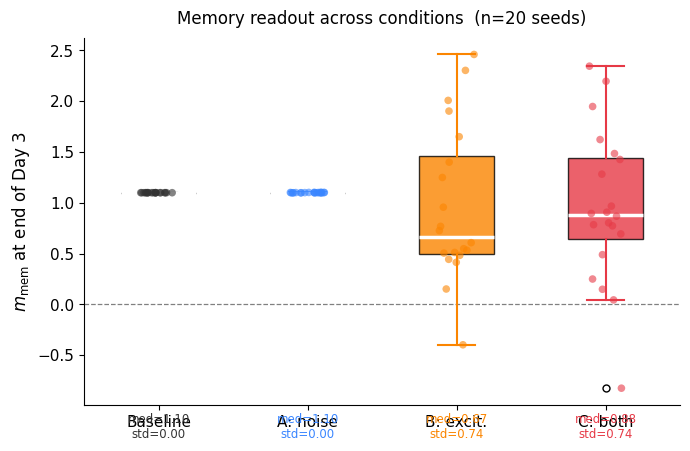

In [12]:
N=10; dt=10.0
PARAMS = dict(N=N,dt=dt,tau_r=10.0,tau_W=2000.0,tau_h=500.0,eta=0.005,lam=0.1,kappa_h=0.2,m_target=0.5,W_scale=0.1,seed=42)
NOISE_STD=0.01; TAU_EPS=1000.0; SIGMA_EPS=0.8
FIG_DIR = Path('/Users/elenaegorova/Library/Mobile Documents/com~apple~CloudDocs/PhD/Computational Neuroscience/project/representational-drift/figures')
I_base = torch.tensor(np.load('/Users/elenaegorova/Library/Mobile Documents/com~apple~CloudDocs/PhD/Computational Neuroscience/project/representational-drift/data/I_base.npy'), dtype=torch.float32)
I_p = torch.full((N,), -3.0)
T_DAY1=T_DAY2=T_DAY3=2000

CONDITIONS = {
    'Baseline':  {'noise_std': 0.0,       'use_eps': False, 'color': '#333333'},
    'A: noise':  {'noise_std': NOISE_STD,  'use_eps': False, 'color': '#3a86ff'},
    'B: excit.': {'noise_std': 0.0,        'use_eps': True,  'color': '#fb8500'},
    'C: both':   {'noise_std': NOISE_STD,  'use_eps': True,  'color': '#e63946'},
}

# Day 1 (deterministic)
net = HebbianNetwork(**PARAMS)
for t in range(T_DAY1):
    net.step(I_base, noise_std=0.0, homeostasis=False)
W_d1 = net.W.clone(); r_d1 = net.r.clone()
r_m_np = r_d1.cpu().numpy(); r_m_norm = np.linalg.norm(r_m_np)

N_SEEDS = 20
from collections import defaultdict
seed_results = defaultdict(list)

for s_idx in range(N_SEEDS):
    for ci, (cname, params) in enumerate(CONDITIONS.items()):
        torch.manual_seed(s_idx * 100 + ci)
        np.random.seed(s_idx * 100 + ci)
        net.W=W_d1.clone(); net.r=r_d1.clone(); net.h=torch.tensor(0.0); net.epsilon=torch.zeros(N)
        for t in range(T_DAY2):
            if params['use_eps']:
                net.epsilon = net.epsilon + dt*(-net.epsilon/TAU_EPS) + SIGMA_EPS*(2*dt/TAU_EPS)**0.5*torch.randn(N)
            net.step(I_p, noise_std=params['noise_std'], homeostasis=False)
        for t in range(T_DAY3):
            if params['use_eps']:
                net.epsilon = net.epsilon + dt*(-net.epsilon/TAU_EPS) + SIGMA_EPS*(2*dt/TAU_EPS)**0.5*torch.randn(N)
            net.step(I_p, noise_std=params['noise_std'], homeostasis=True)
        seed_results[cname].append(net.r.cpu().numpy() @ r_m_np / r_m_norm)

cond_names = list(CONDITIONS.keys())
data = [seed_results[c] for c in cond_names]
colors = [CONDITIONS[c]['color'] for c in cond_names]

fig, ax = plt.subplots(figsize=(7, 5))

bp = ax.boxplot(data, positions=range(len(cond_names)),
                widths=0.5, patch_artist=True,
                medianprops=dict(color='white', linewidth=2.5),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5),
                flierprops=dict(marker='o', markersize=5, linestyle='none'))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
for whisker, cap, color in zip(bp['whiskers'][::2], bp['caps'][::2], colors):
    whisker.set_color(color)
    cap.set_color(color)
for whisker, cap, color in zip(bp['whiskers'][1::2], bp['caps'][1::2], colors):
    whisker.set_color(color)
    cap.set_color(color)

# Overlay individual points with jitter
np.random.seed(1)
for i, (vals, color) in enumerate(zip(data, colors)):
    jitter = np.random.uniform(-0.12, 0.12, len(vals))
    ax.scatter(i + jitter, vals, color=color, s=30, alpha=0.6, zorder=4, edgecolors='none')

ax.axhline(0, color='gray', lw=0.9, ls='--', zorder=1)
ax.set_xticks(range(len(cond_names)))
ax.set_xticklabels(cond_names, fontsize=12)
ax.set_ylabel(r'$m_\mathrm{mem}$ at end of Day 3', fontsize=12)
ax.set_title(f'Memory readout across conditions  (n={N_SEEDS} seeds)', fontsize=12, pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=11)

# Annotate median and std below x-axis
for i, (cname, vals) in enumerate(zip(cond_names, data)):
    vals = np.array(vals)
    ax.text(i, ax.get_ylim()[0] - 0.08,
            f'med={np.median(vals):.2f}\nstd={vals.std():.2f}',
            ha='center', va='top', fontsize=8.5, color=colors[i])

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig(FIG_DIR / 'fig_robustness.png', dpi=150, bbox_inches='tight')
print("Saved fig_robustness.png")

In [11]:
# ============================================================
# Summary statistics
# ============================================================
print('=== Final Summary ===')
print(f'Day 1:  r_m mean = {r_m.mean():.3f},  \u0394W L1/N^2 = {np.abs(dW_d1_np).mean():.5f}')
print()
for cond_name, res in results.items():
    dW_d2  = res['W_end_d2'] - W_struct_np
    dW_d3  = res['W_end_d3'] - W_struct_np
    t1     = np.abs(dW_d1_np).mean()
    pct_d2 = 100 * np.abs(dW_d2).mean() / t1 if t1 > 0 else 0
    pct_d3 = 100 * np.abs(dW_d3).mean() / t1 if t1 > 0 else 0
    print(f'{cond_name:12s}  '
          f'm_mem D3_end={res["m_mem_d3"][-1]:.3f}  '
          f'h D3_end={res["h_d3"][-1]:.3f}  '
          f'trace: D2={pct_d2:.0f}%  D3={pct_d3:.0f}%')

=== Final Summary ===
Day 1:  r_m mean = 0.773,  ΔW L1/N^2 = 0.01239

Baseline      m_mem D3_end=1.100  h D3_end=3.492  trace: D2=37%  D3=53%
A: noise      m_mem D3_end=1.095  h D3_end=3.493  trace: D2=43%  D3=51%
B: excit.     m_mem D3_end=2.885  h D3_end=3.249  trace: D2=37%  D3=88%
C: both       m_mem D3_end=1.236  h D3_end=3.633  trace: D2=45%  D3=72%
